<a href="https://colab.research.google.com/github/Kunj-7007/AI_ML_Workshop_LDRP/blob/Day3/ML_LinearRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt


In [2]:
#Load the dataset
data=pd.read_csv('/content/appliance_energy.csv')
#display first few rows
print (data.head())
print(data.shape)

   Temperature (°C)  Energy Consumption (kWh)
0         22.490802                  2.292604
1         34.014286                  3.251925
2         29.639879                  3.009868
3         26.973170                  1.703533
4         18.120373                  1.702201
(100, 2)


In [3]:
#Define features and target variable
x=data[['Temperature (°C)']]
y=data['Energy Consumption (kWh)']  #1 for effective reduction , 0 otherwis

In [5]:
from sklearn.preprocessing import StandardScaler
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

In [10]:
model=LinearRegression()
model.fit(x_train,y_train)

LinearRegression()

In [14]:

# Make predictions on the scaled test data
y_pred = model.predict(x_test)
y_pred

array([1.6858187 , 3.18154068, 2.96097494, 2.76354868, 2.0370856 ,
       2.36343345, 2.09711944, 3.12445907, 1.60849483, 2.24537556,
       2.34866555, 2.66462648, 3.0387357 , 3.27880886, 1.78664542,
       1.85218469, 2.95922164, 1.70468695, 3.0692904 , 1.87828475])

In [15]:
#Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R2): {r2:.2f}")



Mean Squared Error (MSE): 0.16
R-squared (R2): 0.61


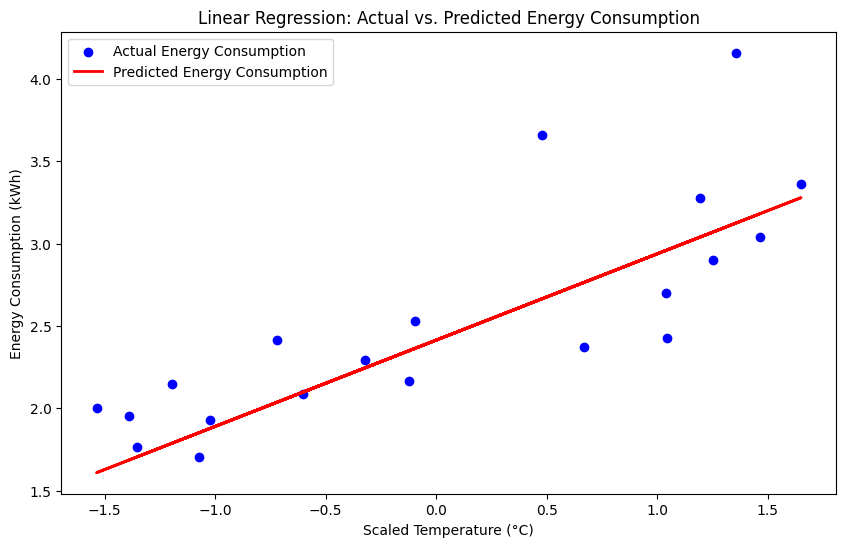

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(x_test, y_test, color='blue', label='Actual Energy Consumption')
plt.plot(x_test, y_pred, color='red', linewidth=2, label='Predicted Energy Consumption')
plt.title('Linear Regression: Actual vs. Predicted Energy Consumption')
plt.xlabel('Scaled Temperature (°C)')
plt.ylabel('Energy Consumption (kWh)')
plt.legend()
plt.show()

In [23]:
print("Train R2:", model.score(x_train, y_train))
print("Test R2:", model.score(x_test, y_test))

Train R2: 0.5644175310361115
Test R2: 0.6119478447399156


In [25]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression

model = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())
model.fit(x_train, y_train)

Pipeline(steps=[('polynomialfeatures', PolynomialFeatures()),
                ('linearregression', LinearRegression())])

In [26]:
# Make predictions on the scaled test data
y_pred = model.predict(x_test)
y_pred

array([1.80069263, 3.27882877, 2.95567789, 2.69728882, 1.99749416,
       2.26303131, 2.04036265, 3.19170873, 1.76976415, 2.1577762 ,
       2.24929448, 2.57878346, 3.0654525 , 3.4328974 , 1.84773913,
       1.88239772, 2.9532549 , 1.8089184 , 3.1098241 , 1.89709443])

In [28]:
#Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R2): {r2:.2f}")


Mean Squared Error (MSE): 0.16
R-squared (R2): 0.62


In [29]:
print("Train R2:", model.score(x_train, y_train))
print("Test R2:", model.score(x_test, y_test))

Train R2: 0.5813559228936354
Test R2: 0.6225493320357702
